# CVD Risk Stratification — Predictive Modeling

**Project:** Cardiovascular Disease Risk Stratification & ED Capacity Planning
**Notebook:** `02_modeling.ipynb`

This notebook builds, tunes, evaluates, and compares a suite of multi-class
classifiers that stratify patients into **Low / Medium / High** cardiovascular
risk. It consumes the model-ready feature store produced by the data-engineering
layer (`data/feature_store/features.parquet`) and exercises the reusable classes
in `src/modeling/`.

### Methodology overview
1. **Feature selection** — Recursive Feature Elimination (RFECV), Mutual
   Information, and Variance Inflation Factor (VIF) for multicollinearity.
2. **Modeling** — Logistic Regression, Random Forest, XGBoost, and Gradient
   Boosting, each inside an end-to-end preprocessing `Pipeline`
   (StandardScaler + OneHotEncoder), tuned with 5-fold `GridSearchCV`.
3. **Imbalance handling** — `class_weight='balanced'` (LR, RF) and SMOTE
   oversampling (XGBoost, Gradient Boosting).
4. **Evaluation** — classification reports, confusion matrices, one-vs-rest
   ROC / PR / calibration curves, feature importance, learning curves.
5. **Inference** — a calibrated `RiskStratifier` interface used by the ED
   Capacity Planning module.

> The `risk_level` target is a tertile bucketing of a latent risk derived from
> the clinical features, so well-tuned models are expected to score very high;
> the exercise validates the full modeling + evaluation machinery.

In [1]:
import os, sys
import warnings
warnings.filterwarnings("ignore")

# Ensure the project root is importable.
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from src.modeling import common
from src.modeling.feature_selector import FeatureSelector
from src.modeling.model_trainer import ModelTrainer
from src.modeling.model_evaluator import ModelEvaluator
from src.modeling.risk_stratifier import RiskStratifier
from src.modeling.model_registry import ModelRegistry

pd.set_option("display.max_columns", 50)
print("Project root:", common.PROJECT_ROOT)

Project root: /home/ubuntu/github_repos/Data-Analytic-Data-Engineering


## 1. Load the feature store

In [2]:
df = common.load_feature_frame()
print("Feature store shape:", df.shape)
print("\nTarget (risk_level) distribution:")
print(df["risk_level"].value_counts())
print("\nNumeric features:", len(common.NUMERIC_FEATURES),
      "| Categorical features:", len(common.CATEGORICAL_FEATURES))
df.head()

Feature store shape: (10000, 53)

Target (risk_level) distribution:
risk_level
Low       7168
Medium    1946
High       886
Name: count, dtype: int64

Numeric features: 16 | Categorical features: 15


,patient_id,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_blood_sugar,rest_ecg,max_heart_rate,exercise_angina,st_depression,st_slope,ca_vessels,thal,target,risk_level,age_z,resting_bp_z,cholesterol_z,max_heart_rate_z,st_depression_z,ca_vessels_z,cp_0,cp_1,cp_2,...,ecg_2,slope_0,slope_1,slope_2,thal_1,thal_2,thal_3,note_count,mentions_chest_pain,mentions_dyspnea,mentions_diabetes,mentions_smoking,mentions_syncope,avg_note_length,age_group,bp_category,cholesterol_category,comorbidity_index,hr_reserve_ratio,framingham_risk_score,ten_year_cvd_risk_pct,ed_visit_count,ed_avg_los_hours,ed_high_acuity_visits,ed_avg_resources
0,P0000001,51,1,2,92,206,0,0,137,0,1.4,2,0,1,0,Low,-0.3296,-1.8907,0.0092,-0.2020,0.4091,-0.7225,0,0,1,...,0,0,0,1,1,0,0,3,0,0,0,1,0,28.0,50-59,Normal,Borderline,1,0.811,7.0,15.98,2.0,2.07,0.0,1.00
1,P0000002,69,1,2,119,197,0,2,160,1,1.4,1,1,3,0,Medium,1.7363,-0.0971,-0.3354,0.9742,0.4091,0.3498,0,0,1,...,1,0,1,0,0,0,1,3,1,1,0,0,0,35.7,60-69,Normal,Desirable,2,1.060,9.0,22.79,3.0,4.65,0.0,6.33
2,P0000003,60,1,0,96,233,0,2,154,0,0.8,0,0,1,0,Low,0.7033,-1.6249,1.0430,0.6674,-0.2515,-0.7225,1,0,0,...,1,1,0,0,1,0,0,1,0,0,0,1,0,33.0,60-69,Normal,Borderline,1,0.962,9.0,22.79,0.0,0.00,0.0,0.00
3,P0000004,56,1,0,151,266,0,2,149,0,0.8,1,0,3,0,Medium,0.2443,2.0287,2.3066,0.4117,-0.2515,-0.7225,1,0,0,...,1,0,1,0,0,0,1,3,1,0,0,1,0,28.3,50-59,Stage2,High,3,0.909,11.0,31.43,4.0,4.44,0.0,3.75
4,P0000005,45,0,0,120,207,0,0,153,0,1.8,0,0,3,0,Low,-1.0182,-0.0306,0.0475,0.6162,0.8495,-0.7225,1,0,0,...,0,1,0,0,0,0,1,1,0,0,0,0,0,26.0,40-49,Elevated,Borderline,0,0.874,5.0,10.91,0.0,0.00,0.0,0.00


In [3]:
splits = common.stratified_splits(df)
for name, (X, y) in splits.items():
    dist = y.map(common.INT_TO_RISK).value_counts().reindex(common.RISK_ORDER)
    print(f"{name:>5}: {X.shape[0]:>5} rows | {dict(dist)}")

train:  7000 rows | {'Low': np.int64(5018), 'Medium': np.int64(1362), 'High': np.int64(620)}
  val:  1500 rows | {'Low': np.int64(1075), 'Medium': np.int64(292), 'High': np.int64(133)}
 test:  1500 rows | {'Low': np.int64(1075), 'Medium': np.int64(292), 'High': np.int64(133)}


## 2. Feature selection (RFE + Mutual Information + VIF)

We combine a model-free dependency measure (mutual information) with a wrapper
method (RFECV over a balanced Random Forest), and separately audit numeric
multicollinearity via VIF.

In [4]:
selector = FeatureSelector(top_n=20)
mi = selector.mutual_information()
mi.head(10)

,feature,mutual_information
0,num__ed_high_acuity_visits,0.291277
1,num__ed_visit_count,0.285148
2,num__ed_avg_resources,0.276755
3,cat__mentions_dyspnea_1,0.242683
4,cat__mentions_dyspnea_0,0.239743
5,num__ed_avg_los_hours,0.238546
6,cat__mentions_chest_pain_1,0.199053
7,cat__mentions_chest_pain_0,0.188874
8,num__ten_year_cvd_risk_pct,0.178431
9,num__framingham_risk_score,0.177406


In [5]:
vif = selector.variance_inflation()
vif.head(10)

,feature,vif,multicollinear_flag
0,max_heart_rate,428.655287,True
1,hr_reserve_ratio,365.966396,True
2,age,67.392870,True
3,framingham_risk_score,31.731134,True
4,ten_year_cvd_risk_pct,22.665587,True
5,comorbidity_index,6.002748,True
6,avg_note_length,5.569550,True
7,ed_visit_count,3.535734,False
8,ed_avg_los_hours,3.333095,False
9,ed_avg_resources,3.166143,False


Top-20 selected features:
   1. num__ed_high_acuity_visits
   2. num__ed_visit_count
   3. num__ed_avg_resources
   4. cat__mentions_dyspnea_1
   5. cat__mentions_dyspnea_0
   6. num__ed_avg_los_hours
   7. cat__mentions_chest_pain_1
   8. cat__mentions_chest_pain_0
   9. num__ten_year_cvd_risk_pct
  10. num__framingham_risk_score
  11. num__comorbidity_index
  12. num__avg_note_length
  13. cat__mentions_syncope_1
  14. cat__mentions_syncope_0
  15. num__max_heart_rate
  16. num__note_count
  17. num__ca_vessels
  18. num__age
  19. num__hr_reserve_ratio
  20. cat__mentions_smoking_0


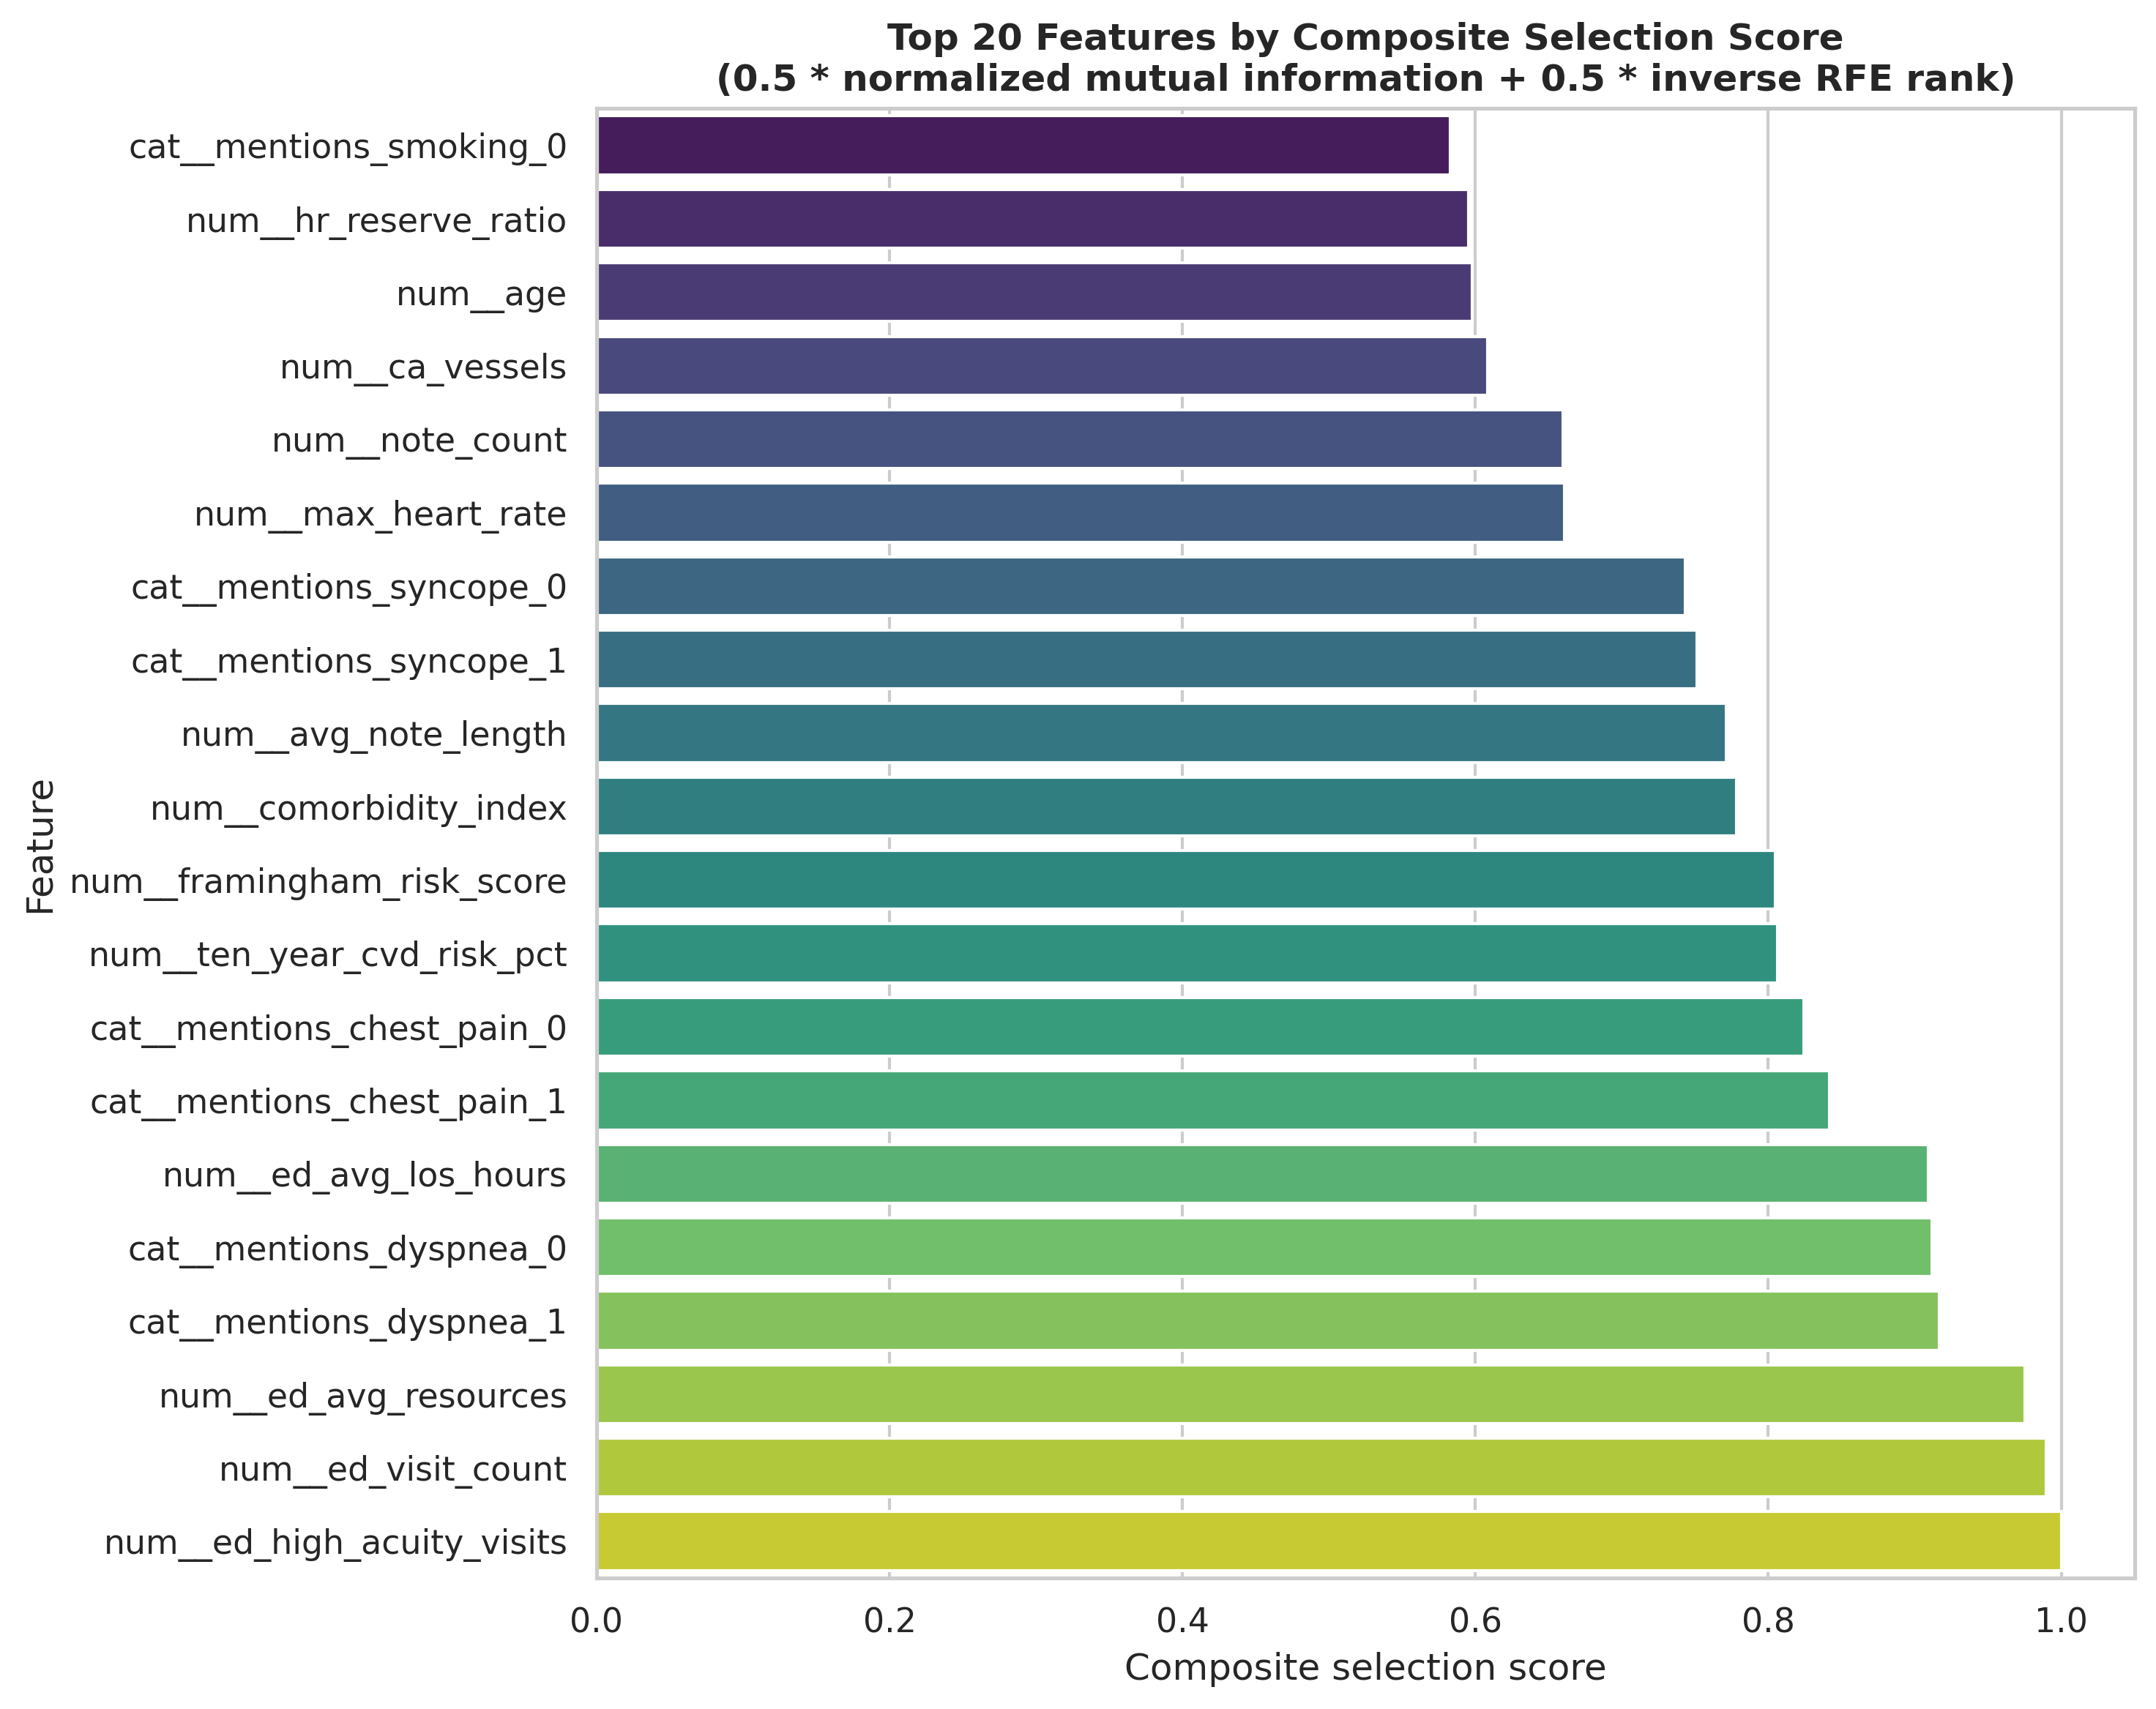

In [6]:
# Full selection (RFE + composite ranking) + export + figure.
selected = selector.run()
print("Top-20 selected features:")
for i, f in enumerate(selected, 1):
    print(f"  {i:2d}. {f}")
display(Image(filename=os.path.join(common.FIGURES_DIR, "feature_selection_ranking.png")))

**Interpretation.** The Emergency-Department utilisation features
(`ed_high_acuity_visits`, `ed_visit_count`, `ed_avg_resources`) and the
symptom-mention flags carry the most information about the risk bucket, followed
by the Framingham-derived scores. VIF flags expected collinearity between
`max_heart_rate` / `hr_reserve_ratio` and between the two Framingham scores —
the tree ensembles are robust to this, and the pipelines standardize inputs.

## 3. Model training & hyperparameter tuning

Each model is wrapped in a preprocessing `Pipeline` and tuned with 5-fold
`GridSearchCV` (scoring = macro-F1). Fitted pipelines are persisted to
`models/*.pkl` and recorded in the `ModelRegistry`.

> Set `RUN_TRAINING = True` to retrain from scratch. By default the notebook
> reuses the artifacts already produced by `python -m src.modeling.run_pipeline`
> so it renders quickly.

In [7]:
RUN_TRAINING = False  # flip to True to retrain (a few minutes)

if RUN_TRAINING:
    trainer = ModelTrainer(search="grid")
    results = trainer.train_all()
else:
    print("Reusing existing model artifacts in models/.")

pd.read_csv(os.path.join(common.REPORTS_DIR, "training_summary.csv"))

Reusing existing model artifacts in models/.


,model,cv_best_f1_macro,val_accuracy,val_f1_macro,val_roc_auc_ovr,train_time_sec
0,logistic_regression,0.989416,0.995333,0.990496,0.999931,1.219843
1,xgboost,0.965626,0.979333,0.964913,0.997942,32.570282
2,gradient_boosting,0.967007,0.975333,0.959458,0.998057,226.852284
3,random_forest,0.949506,0.956667,0.931570,0.993592,12.386330


## 4. Model evaluation & comparison

In [8]:
evaluator = ModelEvaluator()
eval_table = evaluator.evaluate()
evaluator.export_report()
eval_table

,model,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,roc_auc_ovr_macro
0,logistic_regression,0.996000,0.994058,0.995112,0.994565,0.996010,0.999957
1,best_model_calibrated,0.994667,0.994198,0.985409,0.989726,0.994649,0.999326
2,xgboost,0.978667,0.971891,0.947925,0.959473,0.978420,0.998101
3,gradient_boosting,0.974000,0.966315,0.941064,0.953173,0.973733,0.997176
4,random_forest,0.962000,0.946078,0.922839,0.933445,0.961908,0.994356


In [9]:
per_class = pd.read_csv(os.path.join(common.REPORTS_DIR,
                                     "model_evaluation_per_class.csv"))
per_class

,model,risk_level,precision,recall,f1_score,support
0,best_model_calibrated,Low,0.996293,1.000000,0.998143,1075.0
1,best_model_calibrated,Medium,0.986301,0.986301,0.986301,292.0
2,best_model_calibrated,High,1.000000,0.969925,0.984733,133.0
3,gradient_boosting,Low,0.982569,0.996279,0.989376,1075.0
4,gradient_boosting,Medium,0.940767,0.924658,0.932642,292.0
5,gradient_boosting,High,0.975610,0.902256,0.937500,133.0
6,logistic_regression,Low,0.999067,0.996279,0.997671,1075.0
7,logistic_regression,Medium,0.983108,0.996575,0.989796,292.0
8,logistic_regression,High,1.000000,0.992481,0.996226,133.0
9,random_forest,Low,0.981481,0.986047,0.983759,1075.0


### 4.1 Confusion matrices

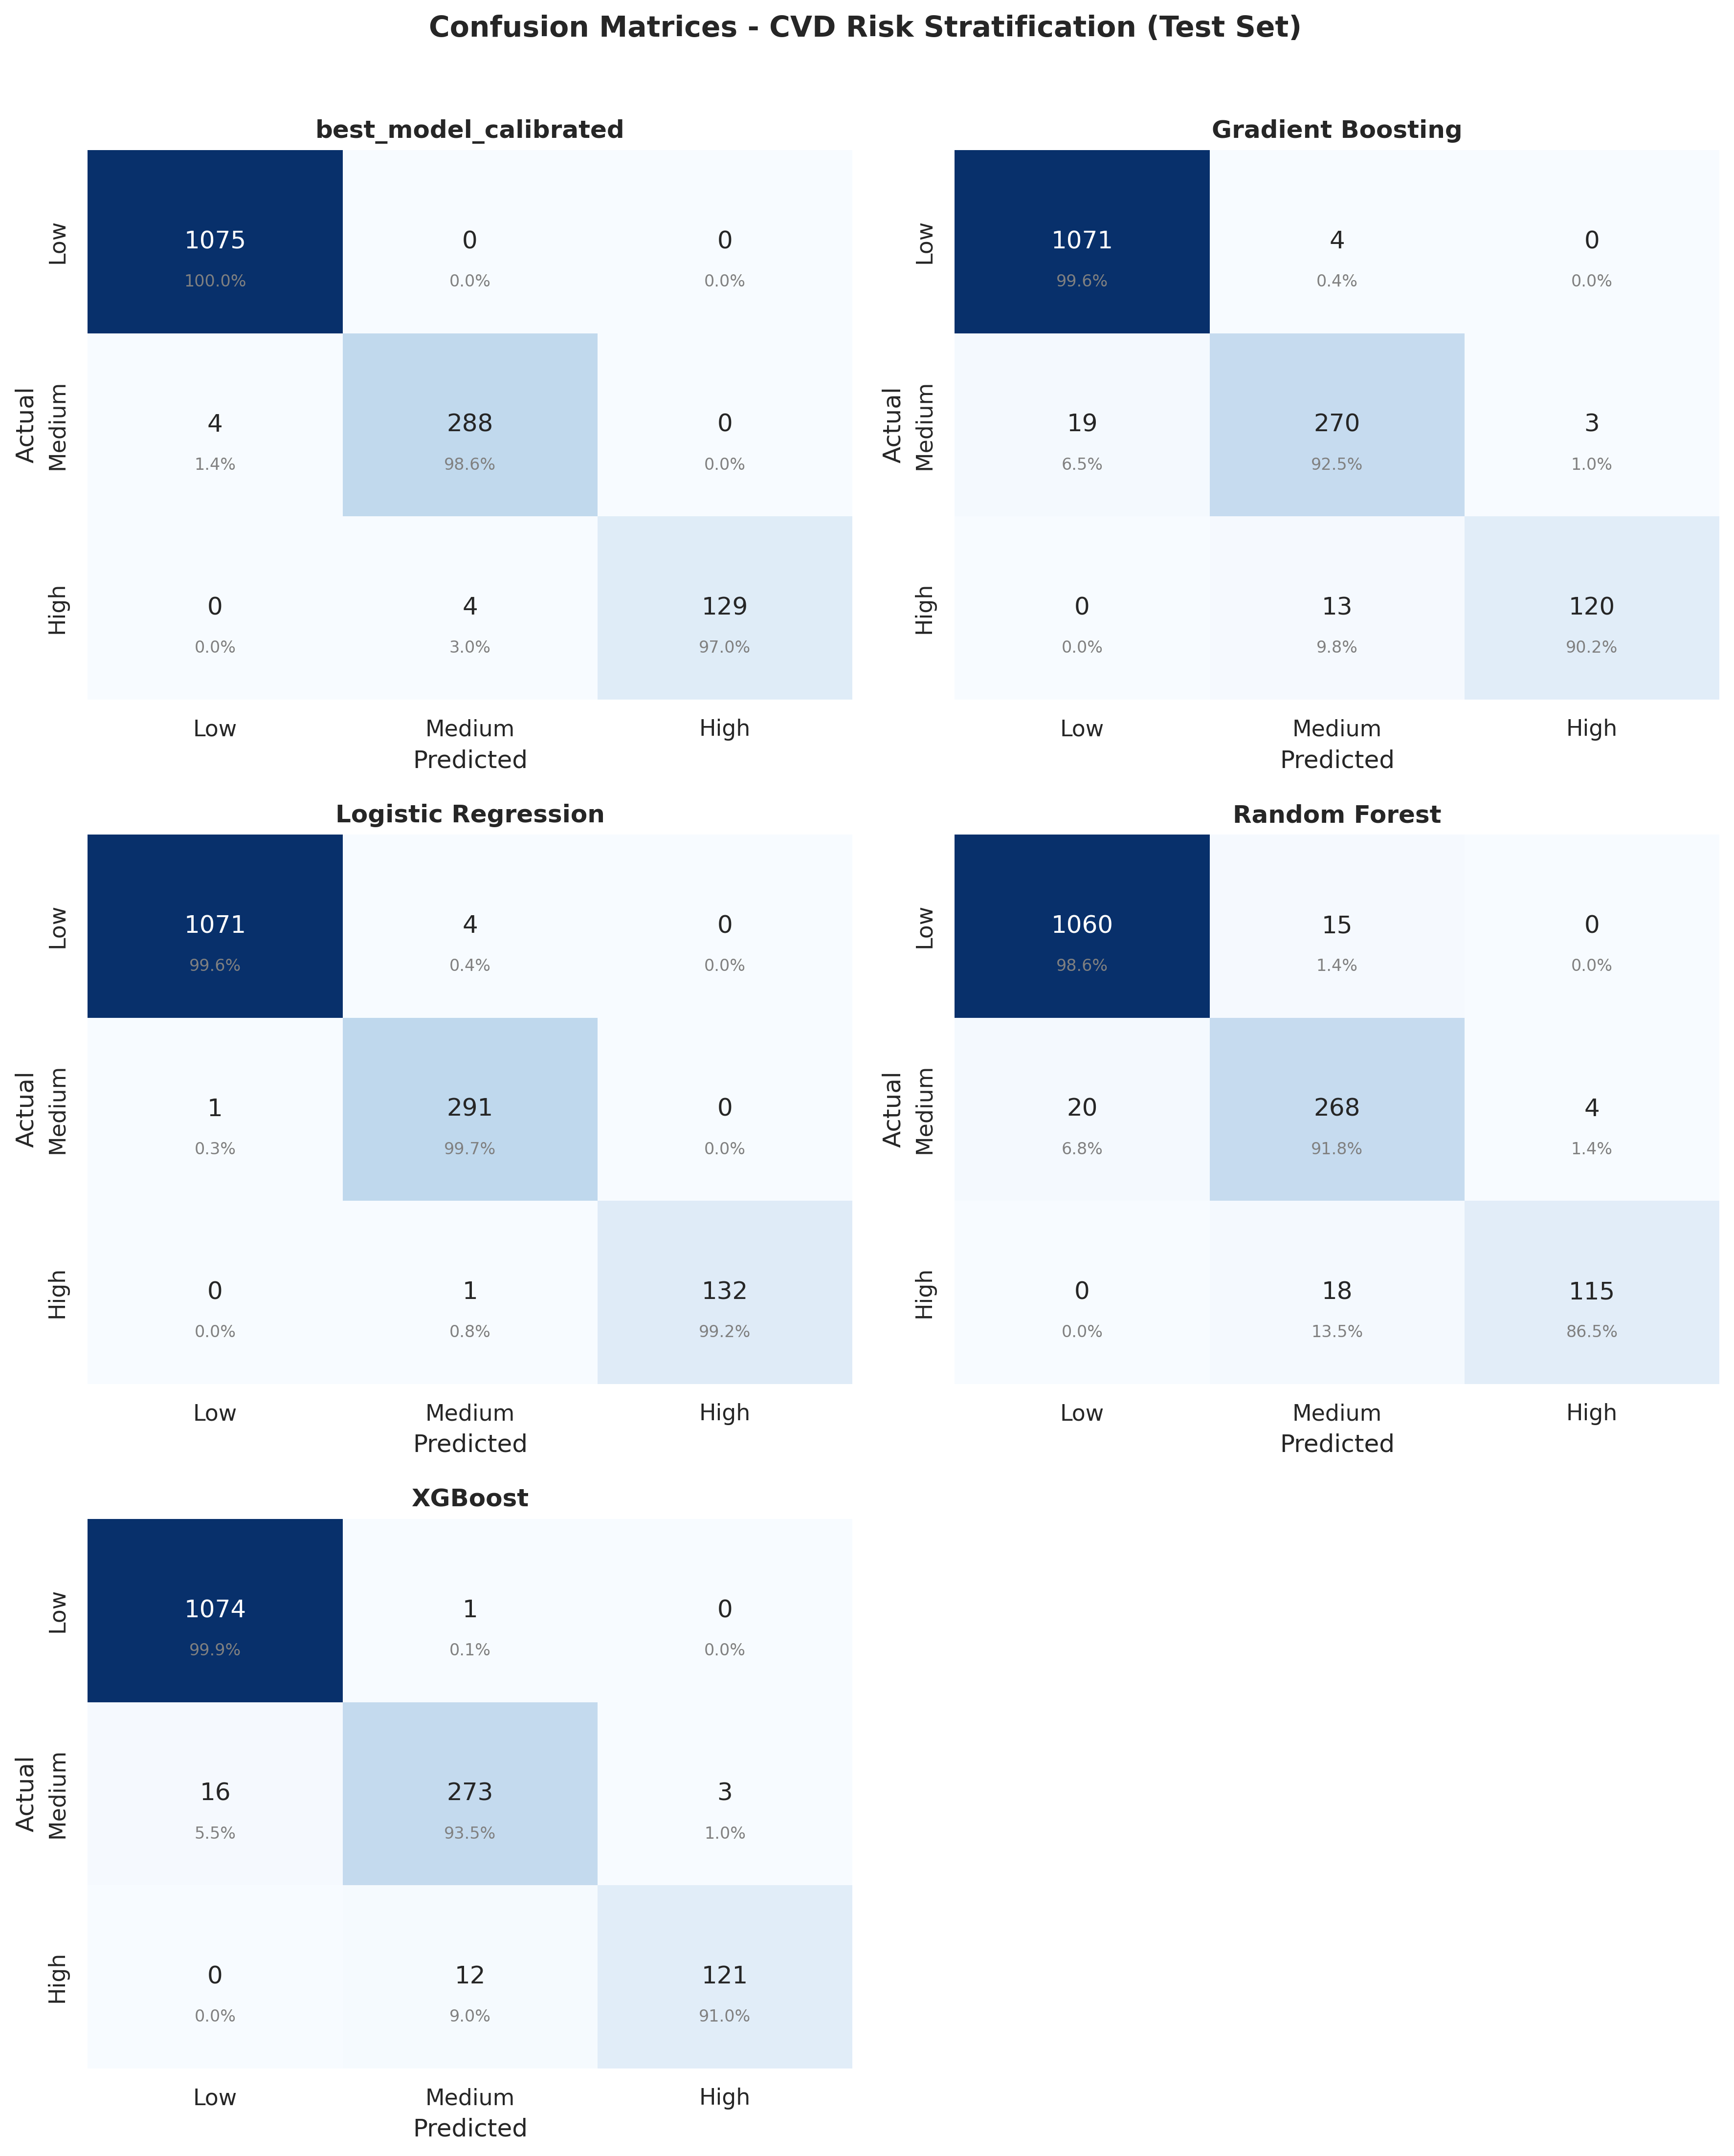

In [10]:
evaluator.plot_confusion_matrices()
display(Image(filename=os.path.join(common.FIGURES_DIR, "confusion_matrices.png")))

### 4.2 ROC curves (one-vs-rest)

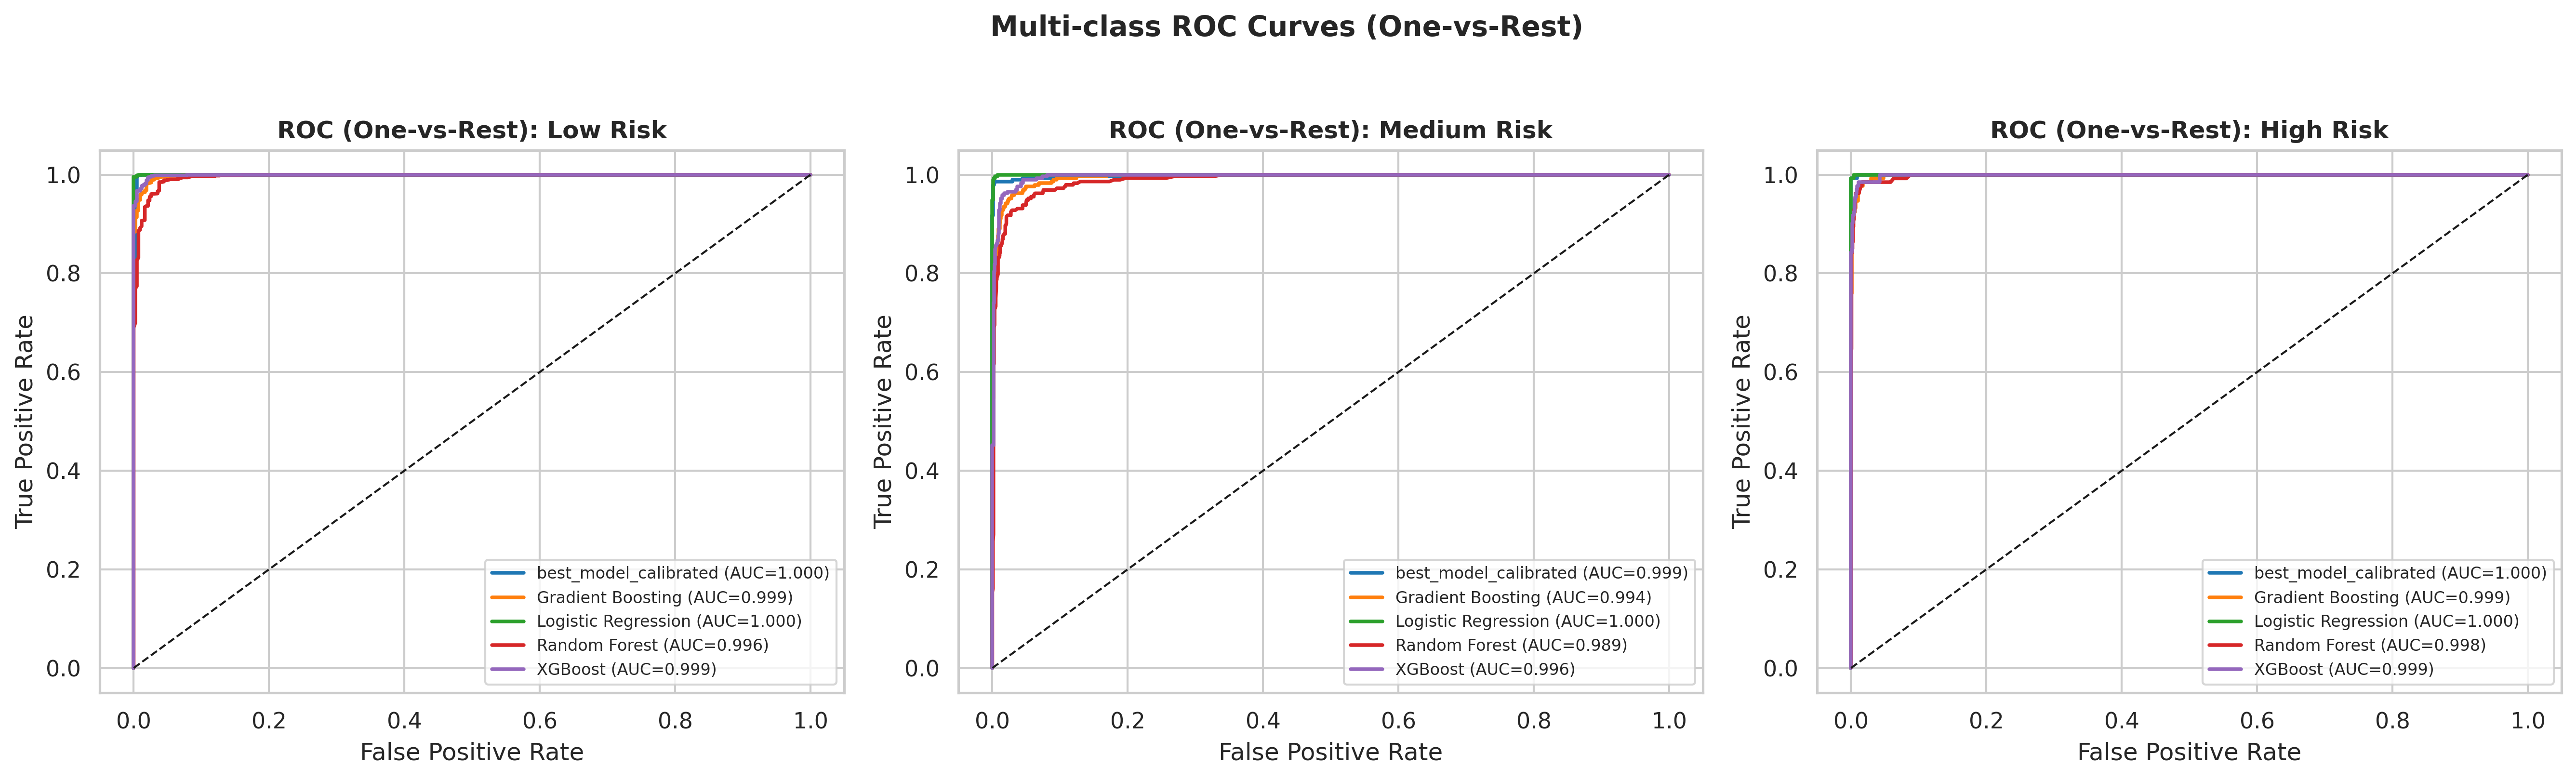

In [11]:
evaluator.plot_roc_curves()
display(Image(filename=os.path.join(common.FIGURES_DIR, "roc_curves_comparison.png")))

### 4.3 Precision–Recall & calibration curves

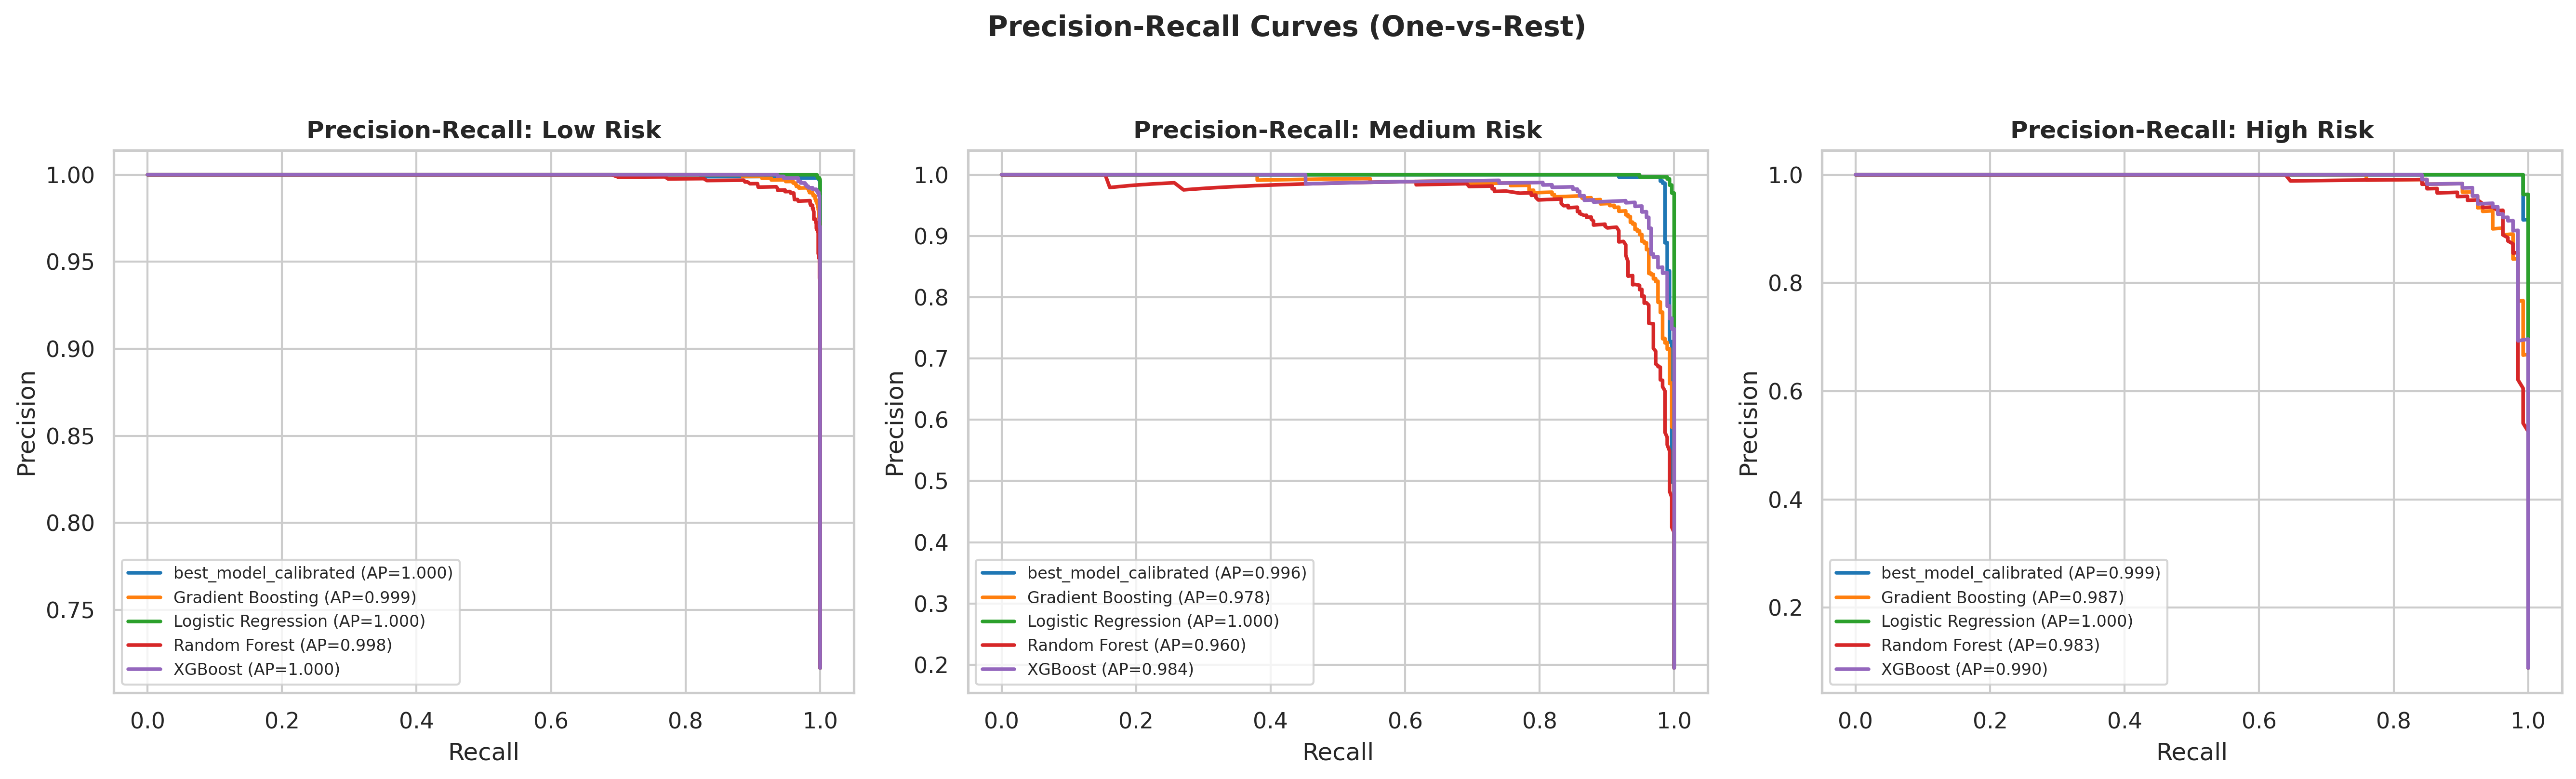

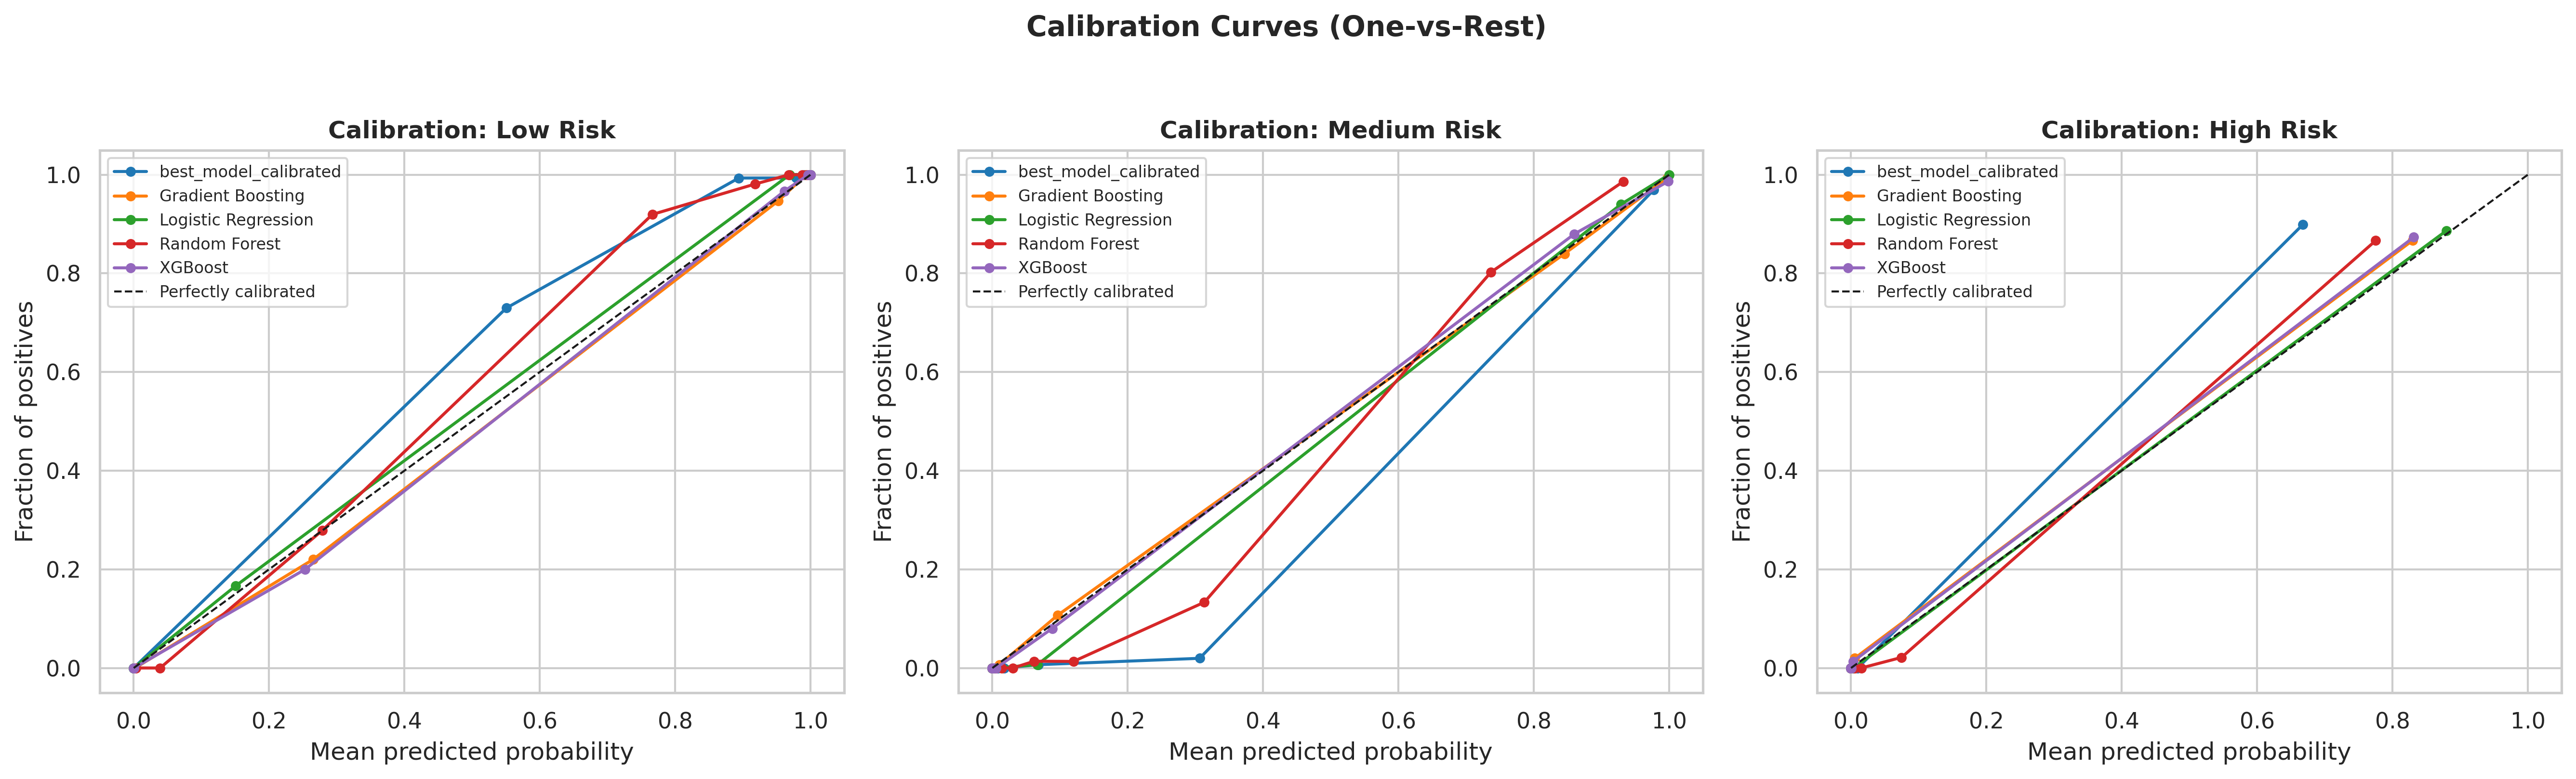

In [12]:
evaluator.plot_precision_recall()
evaluator.plot_calibration()
display(Image(filename=os.path.join(common.FIGURES_DIR, "precision_recall_curves.png")))
display(Image(filename=os.path.join(common.FIGURES_DIR, "calibration_curves.png")))

### 4.4 Feature importance (tree ensembles)

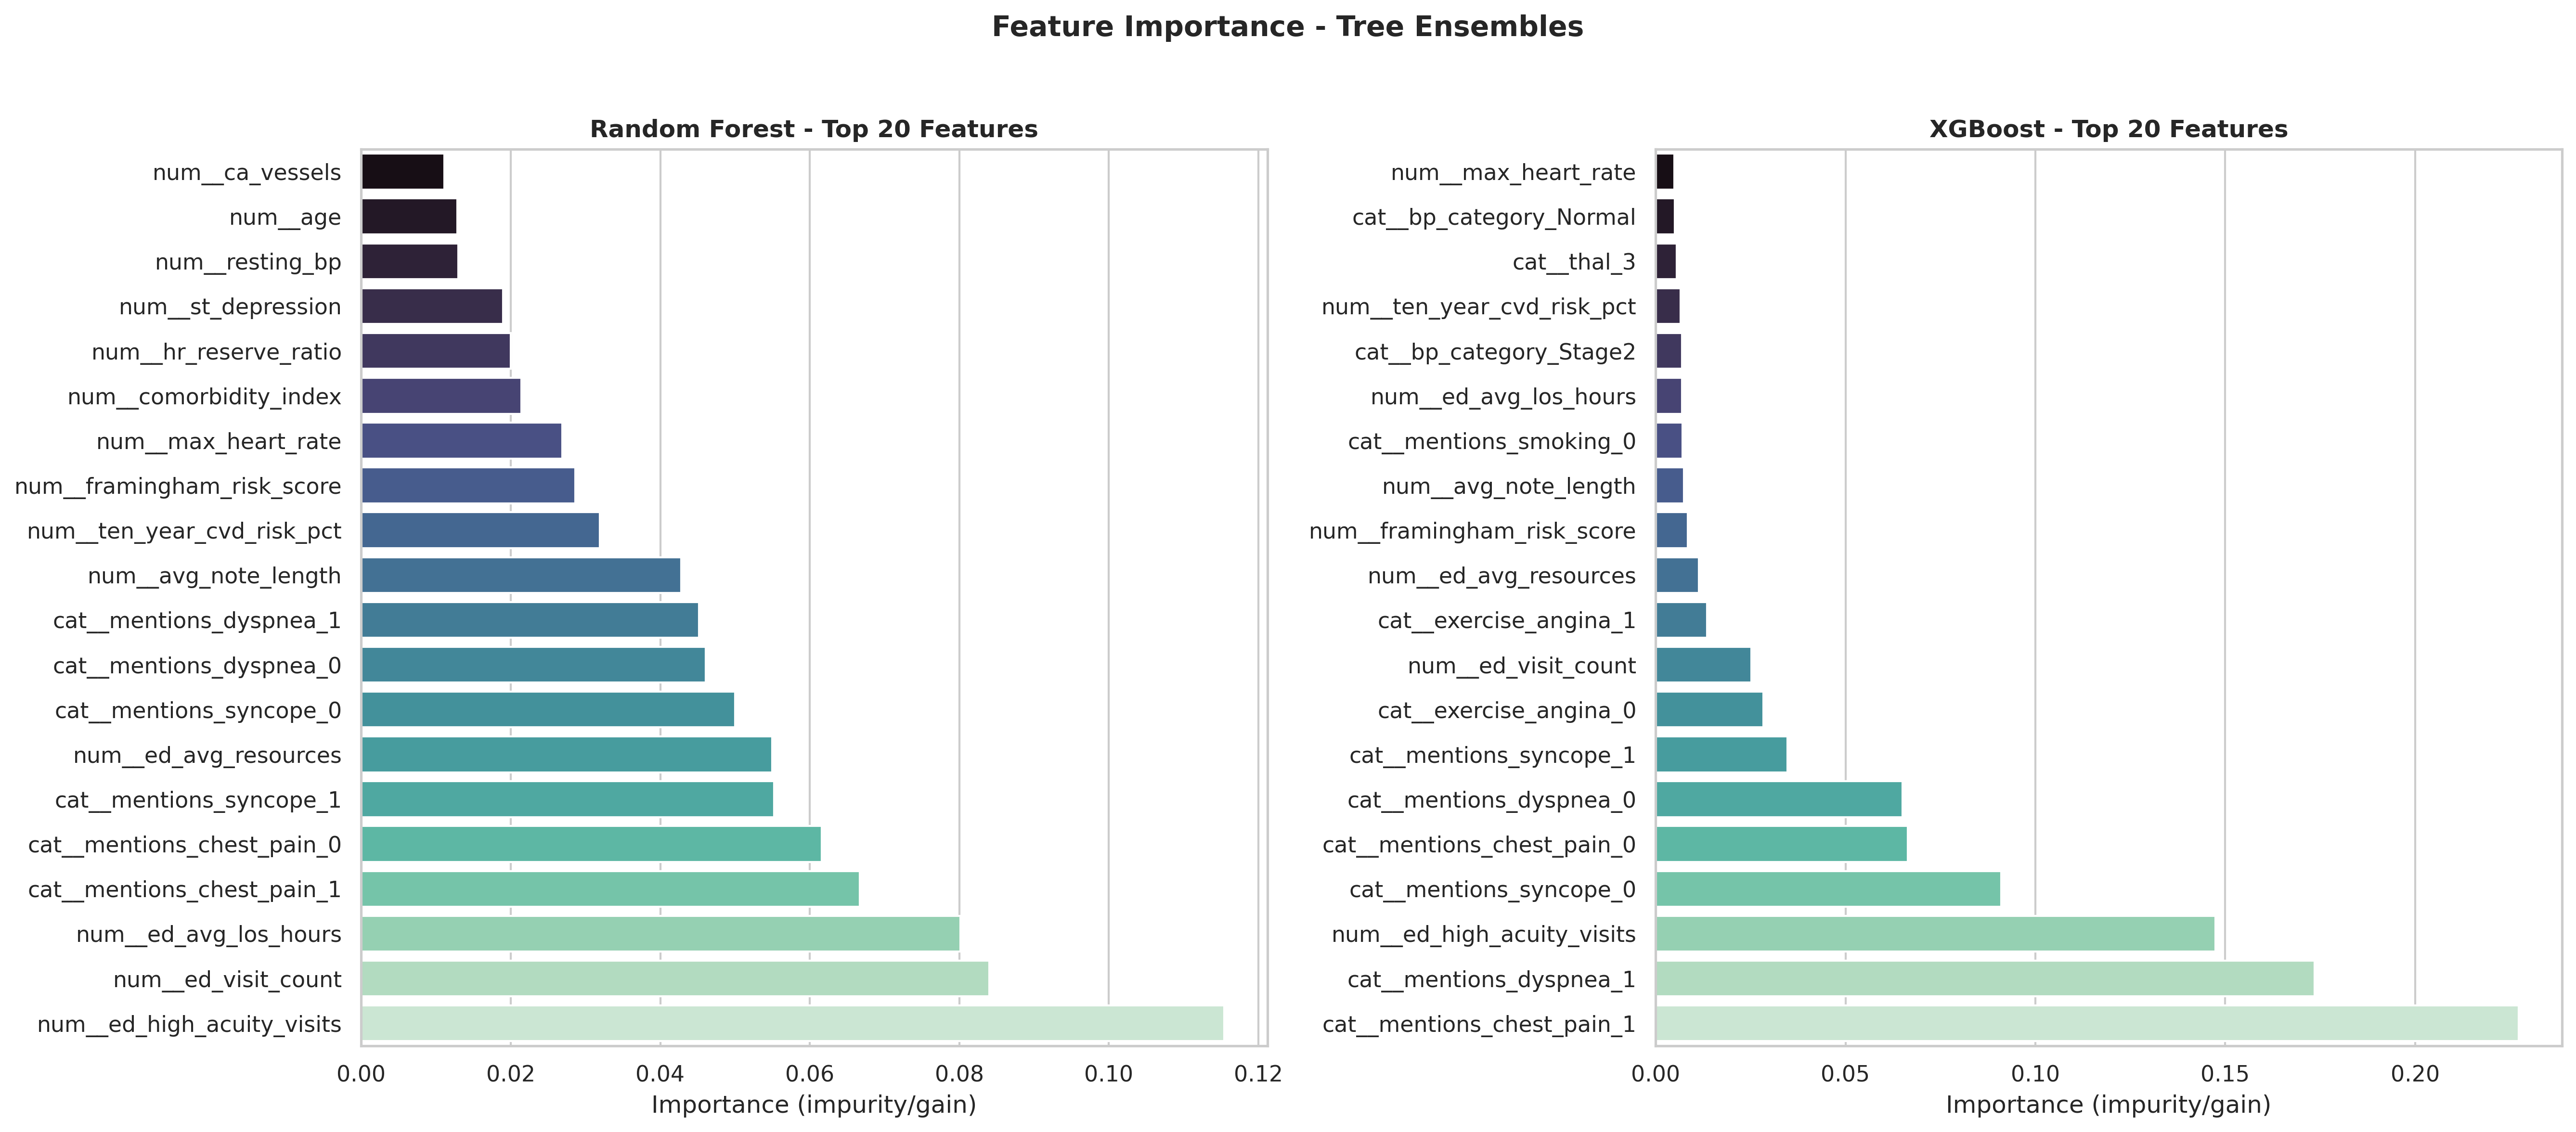

In [13]:
evaluator.plot_feature_importance()
display(Image(filename=os.path.join(common.FIGURES_DIR, "feature_importance.png")))

### 4.5 Model comparison & learning curve

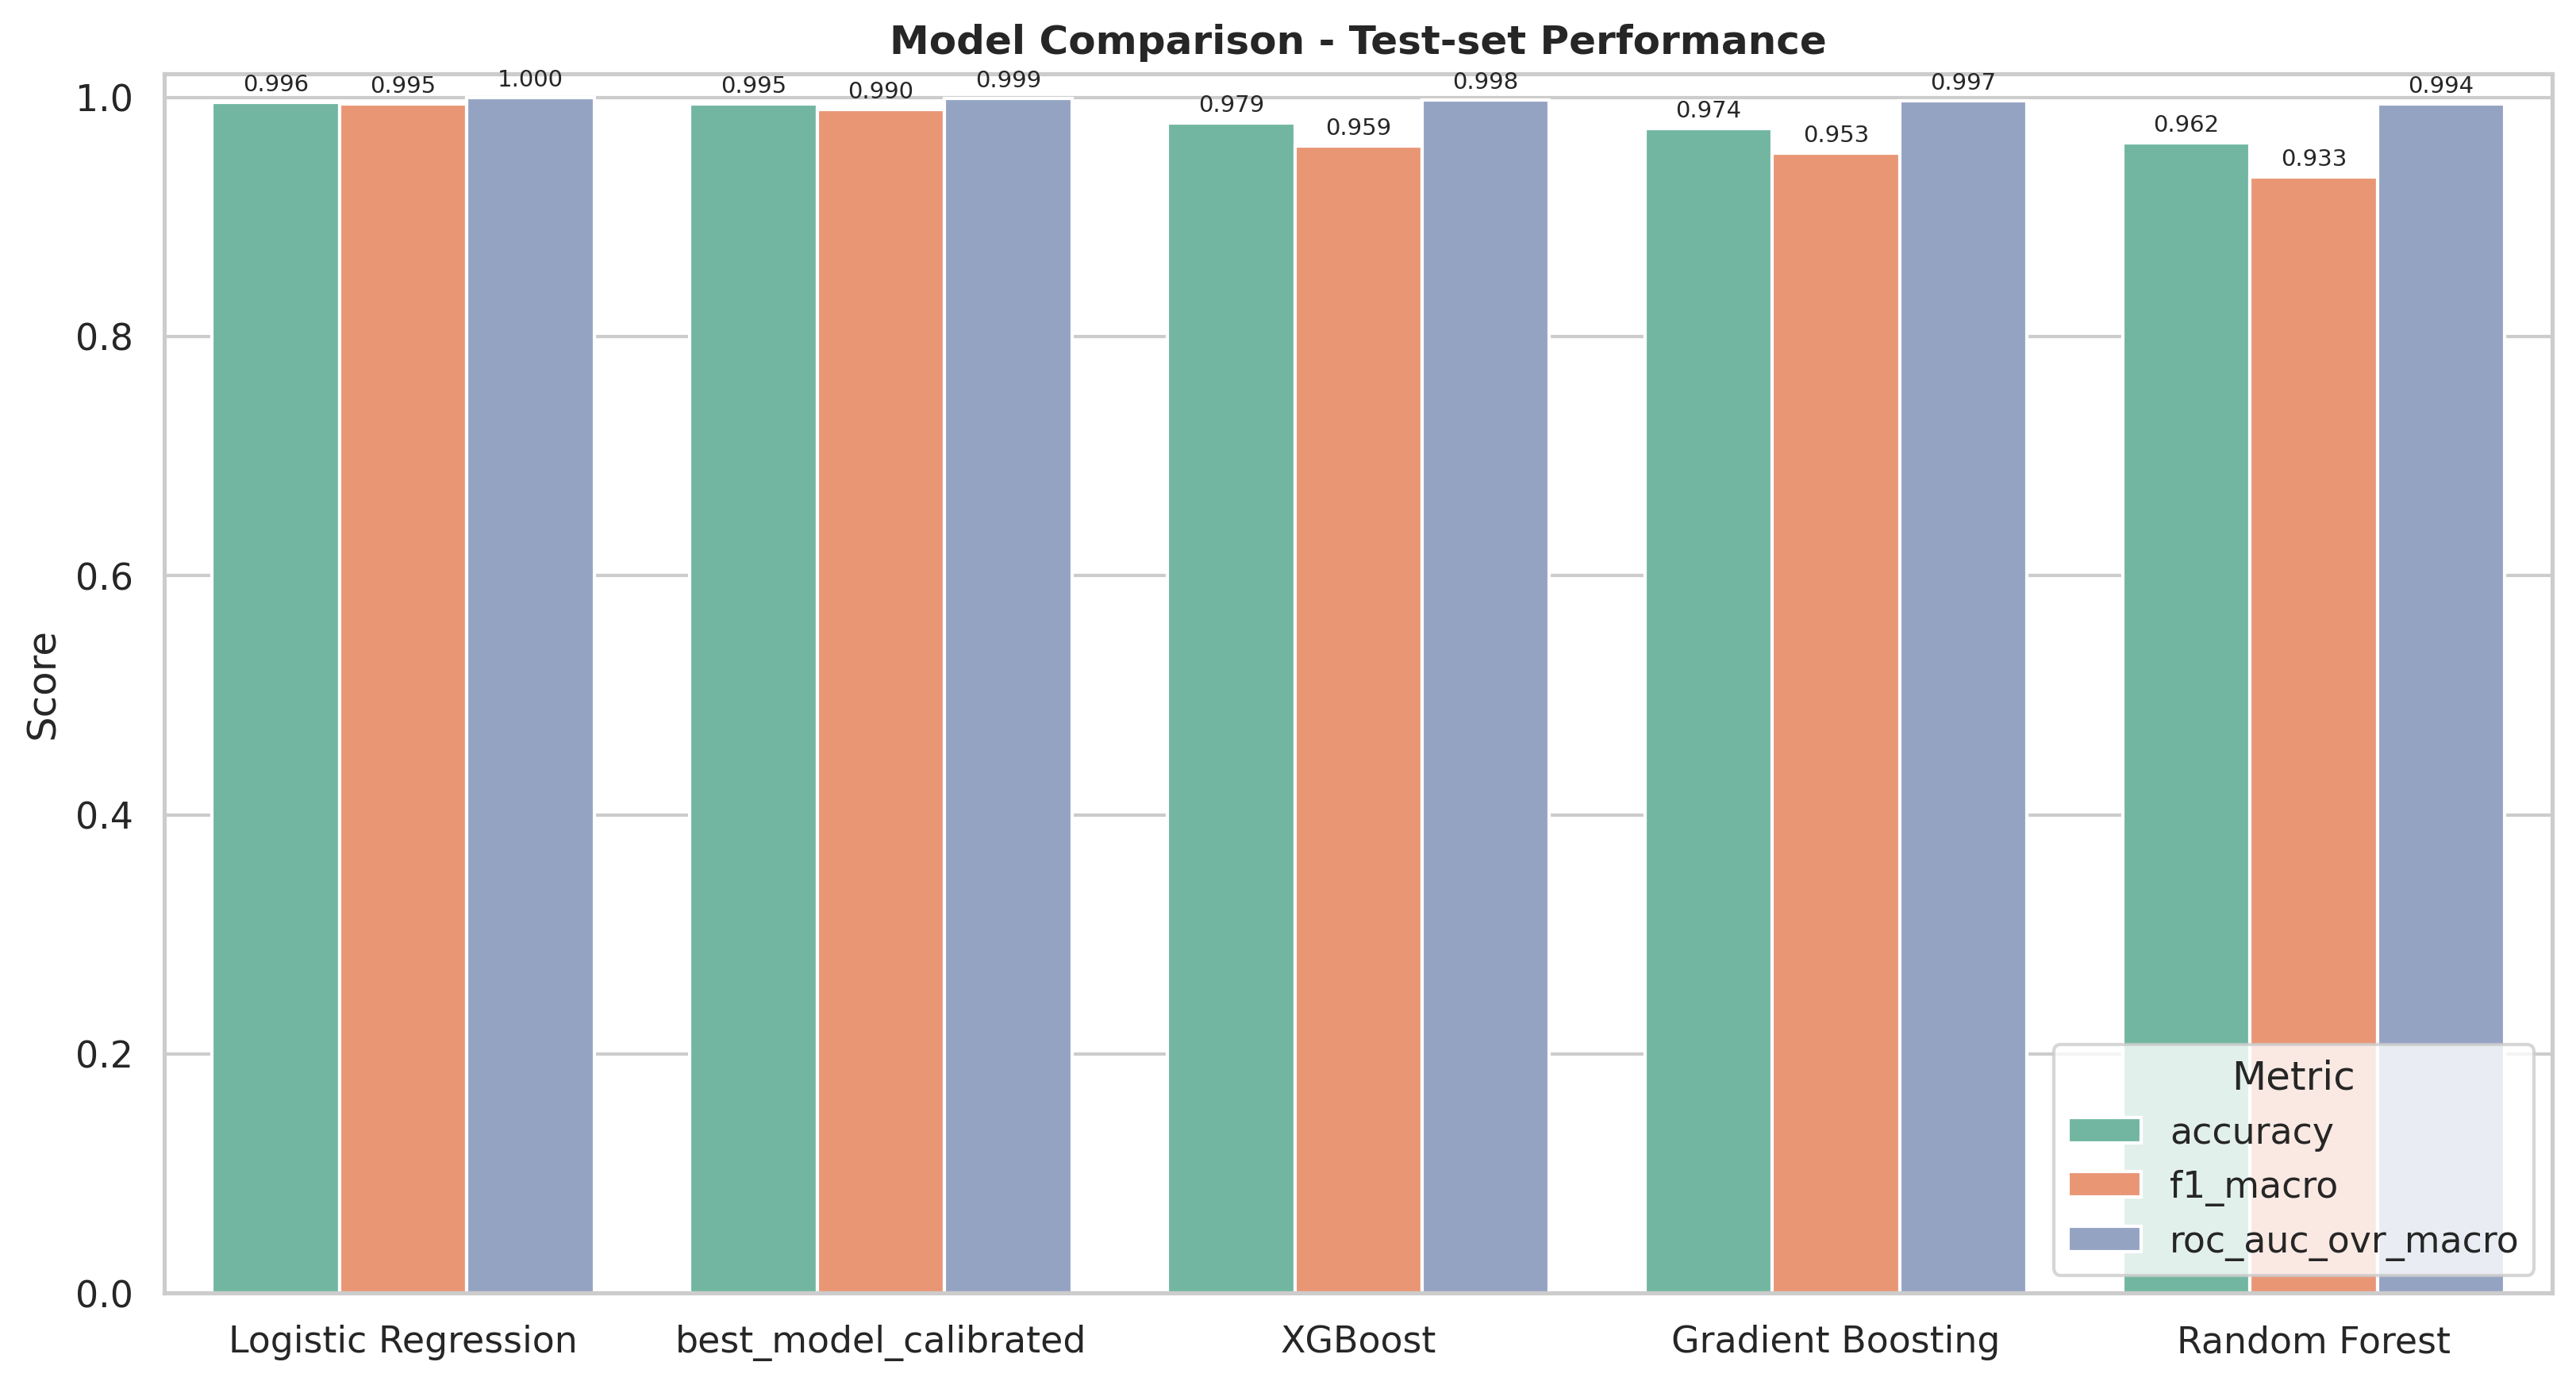

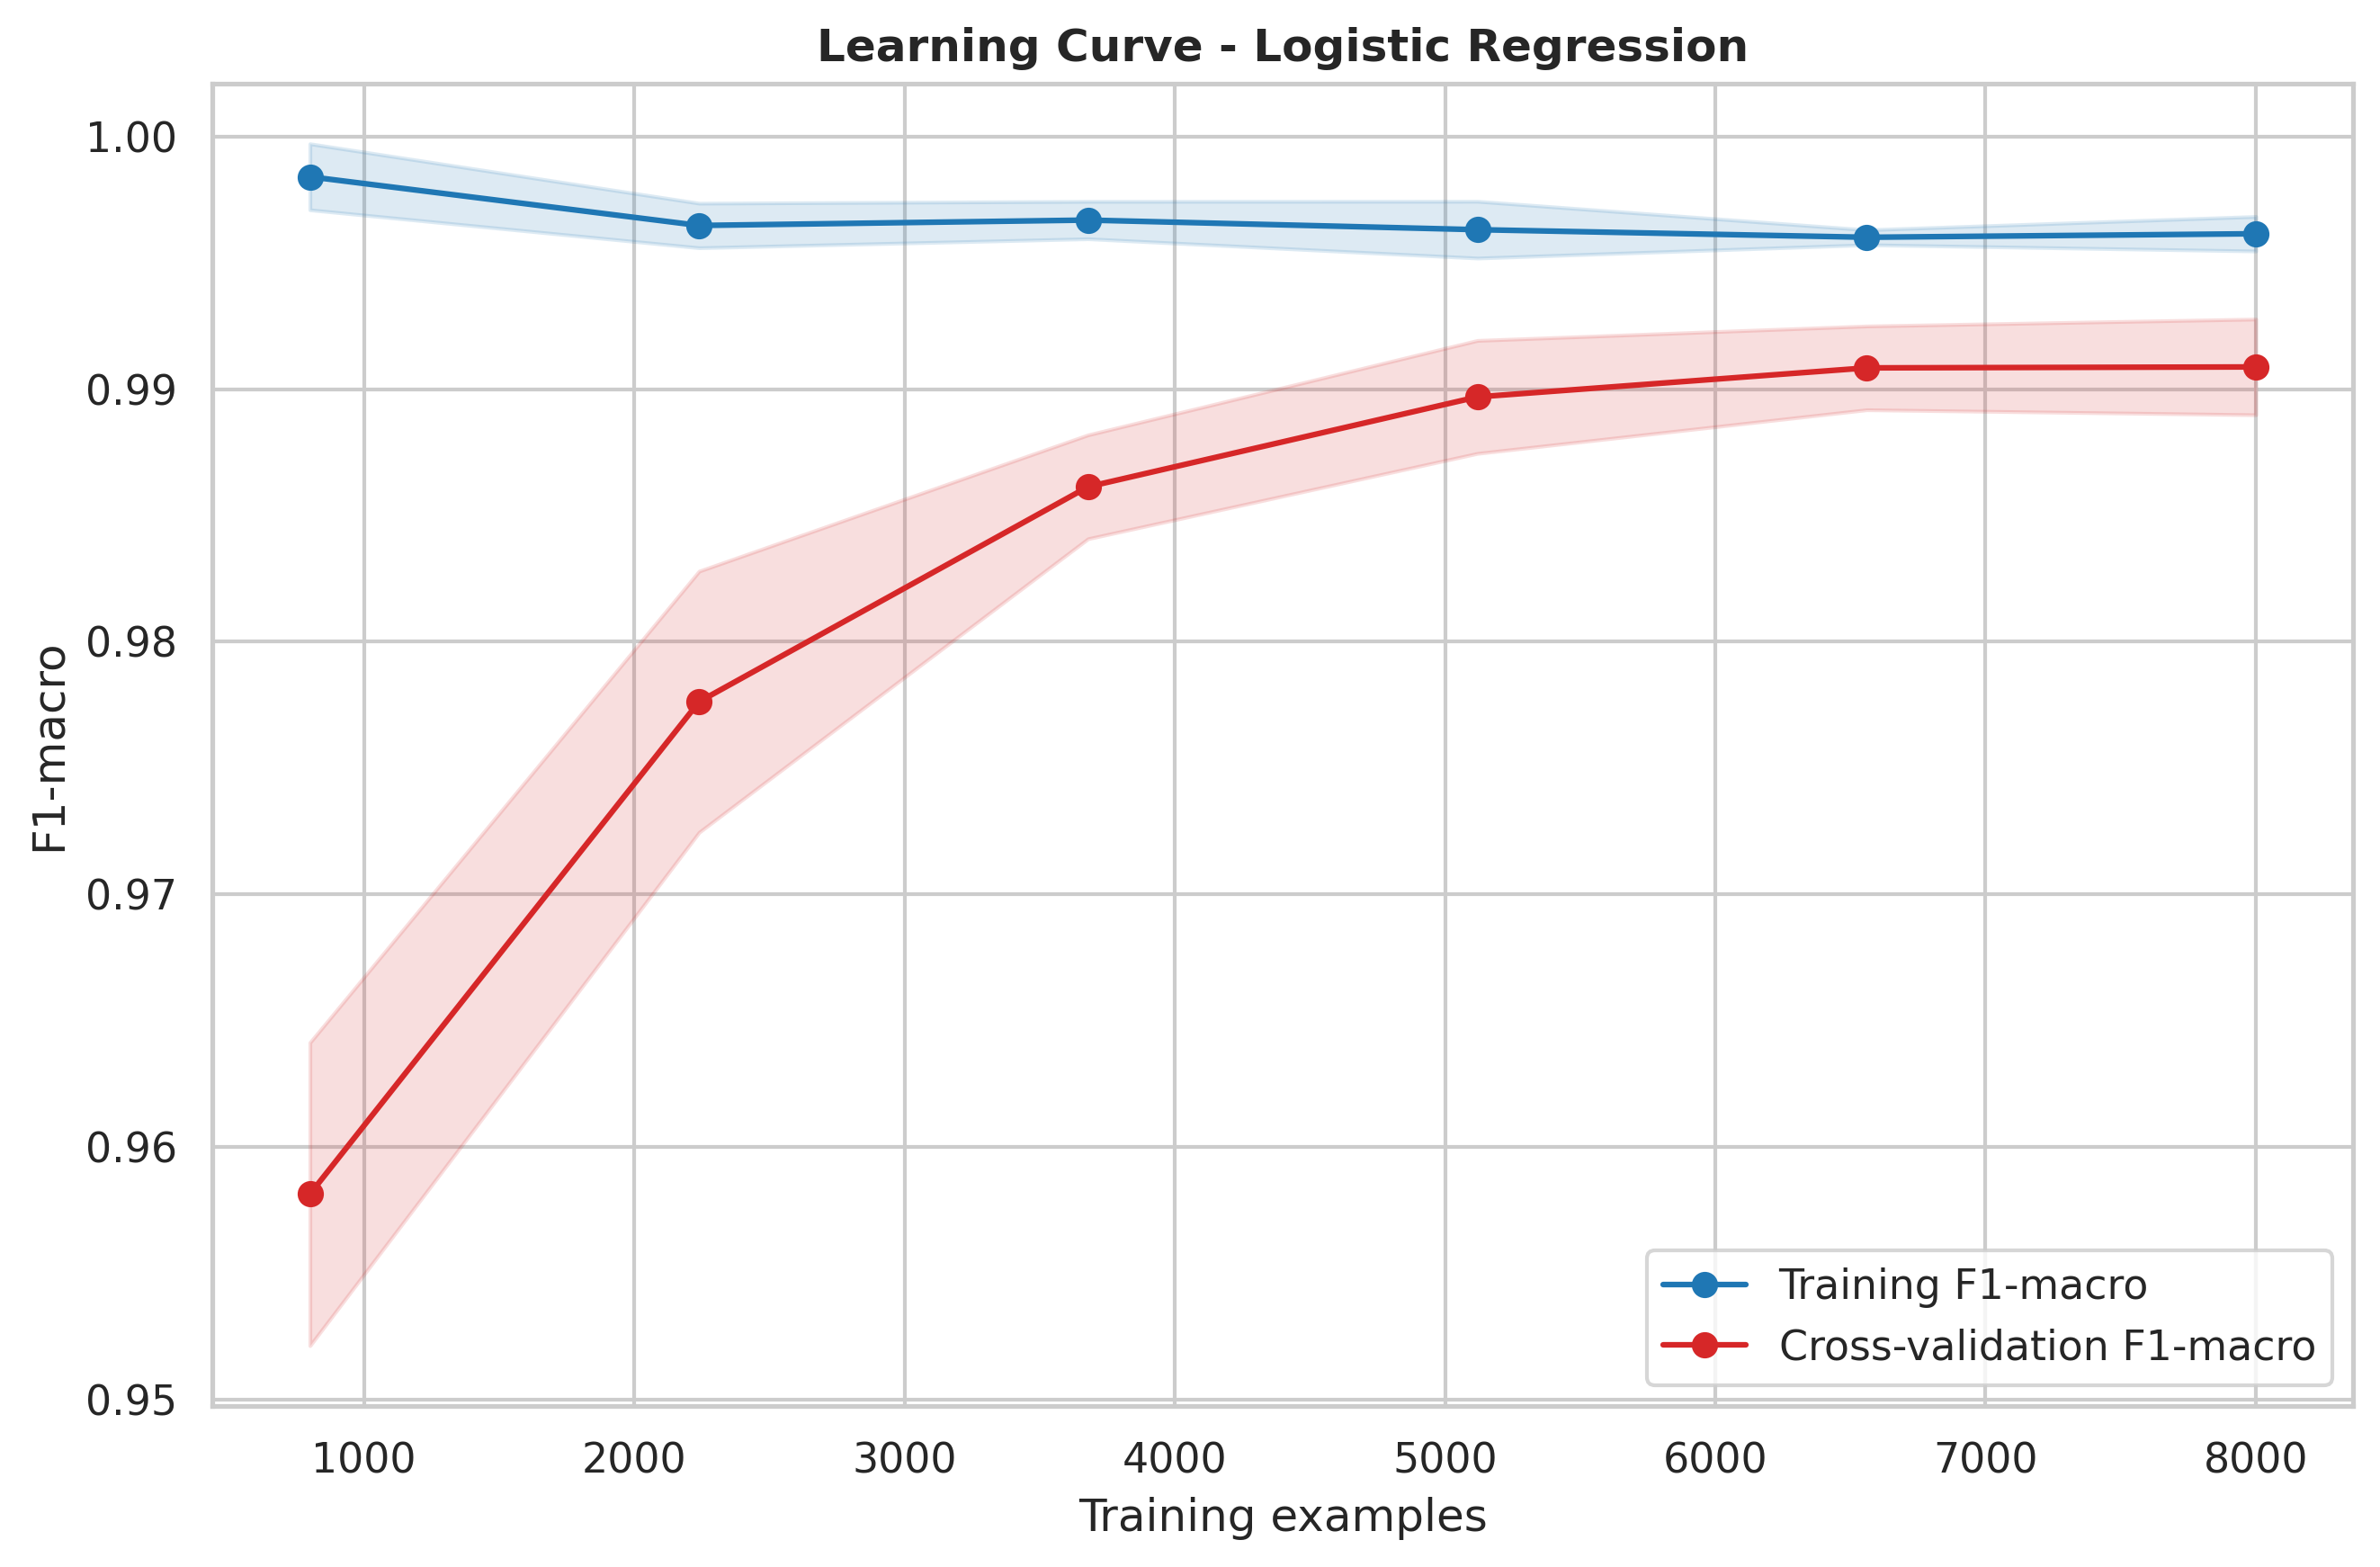

In [14]:
evaluator.plot_model_comparison()
evaluator.plot_learning_curve()
display(Image(filename=os.path.join(common.FIGURES_DIR, "model_comparison.png")))
display(Image(filename=os.path.join(common.FIGURES_DIR, "learning_curve_best_model.png")))

## 5. Model selection rationale

The consolidated table below is sorted by **macro-F1** on the held-out test set,
which is our primary selection metric because it weights all three risk classes
equally despite the class imbalance (Low ≫ Medium > High).

In [15]:
registry = ModelRegistry()
print(registry.summary())
best = registry.get_best_model()
print("\nSelected best model:", best["name"], "->", best["artifact_path"])

Model Registry Summary
BEST: logistic_regression v1 (f1_macro=0.9905)
------------------------------------------------------------
gradient_boosting      v1 | acc=0.9753 f1=0.9595 auc=0.9981
logistic_regression    v1 | acc=0.9953 f1=0.9905 auc=0.9999
random_forest          v1 | acc=0.9567 f1=0.9316 auc=0.9936
xgboost                v1 | acc=0.9793 f1=0.9649 auc=0.9979

Selected best model: logistic_regression -> models/logistic_regression.pkl


**Decision.** All four models achieve strong separation. **Logistic
Regression** attains the top macro-F1 and near-perfect ROC-AUC while being the
smallest, fastest, and most interpretable artifact — so it is registered as the
best model. XGBoost and Gradient Boosting are close behind and provide
non-linear ensemble alternatives; Random Forest trails slightly on the minority
(High) class recall.

## 6. Inference interface — `RiskStratifier`

`RiskStratifier` loads the registered best model, wraps it in a calibrated
classifier for well-behaved probabilities, and is the interface consumed by the
ED Capacity Planning module.

In [16]:
strat = RiskStratifier(calibrate=True)

patient = {
    "age": 63, "sex": 1, "chest_pain_type": 3, "resting_bp": 145,
    "cholesterol": 260, "fasting_blood_sugar": 1, "rest_ecg": 2,
    "max_heart_rate": 120, "exercise_angina": 1, "st_depression": 2.6,
    "st_slope": 1, "ca_vessels": 2, "thal": 3, "comorbidity_index": 3,
    "hr_reserve_ratio": 0.5, "framingham_risk_score": 18.0,
    "ten_year_cvd_risk_pct": 22.0, "note_count": 3, "avg_note_length": 240.0,
    "ed_visit_count": 2, "ed_avg_los_hours": 6.0, "ed_high_acuity_visits": 1,
    "ed_avg_resources": 3.0, "age_group": "60-69", "bp_category": "Stage2",
    "cholesterol_category": "High", "mentions_chest_pain": 1,
    "mentions_dyspnea": 1, "mentions_diabetes": 1, "mentions_smoking": 0,
    "mentions_syncope": 0,
}
strat.predict_risk(patient)

{'risk_level': 'High',
 'risk_code': 2,
 'probabilities': {'Low': 0.0, 'Medium': 0.0, 'High': 1.0},
 'model': 'logistic_regression',
 'calibrated': True}

In [17]:
# Batch inference over a sample of the feature store.
sample = df.sample(8, random_state=1).drop(columns=["risk_level"])
preds = strat.batch_predict(sample)
preds[["patient_id", "risk_level", "prob_Low", "prob_Medium", "prob_High"]]

,patient_id,risk_level,prob_Low,prob_Medium,prob_High
9953,P0009954,Low,0.994043,0.005957,0.000000
3850,P0003851,Low,0.980639,0.019361,0.000000
4962,P0004963,Low,0.999585,0.000415,0.000000
3886,P0003887,High,0.000000,0.088542,0.911458
5437,P0005438,Low,1.000000,0.000000,0.000000
8517,P0008518,Low,0.892702,0.107298,0.000000
2041,P0002042,Low,0.999585,0.000415,0.000000
1989,P0001990,Low,0.997021,0.002979,0.000000


In [18]:
# Predicted risk-mix over a larger sample (feeds the ED capacity module).
dist = strat.get_risk_distribution(df.sample(2000, random_state=2))
print(dist)
dist.plot(kind="bar", color=[common.RISK_PALETTE[r] for r in dist.index],
          title="Predicted risk distribution (n=2000)")
plt.ylabel("Patients"); plt.tight_layout(); plt.show()

risk_level
Low       1458
Medium     377
High       165
Name: count, dtype: int64


## 7. Summary

* Built a complete, reusable modeling package (`src/modeling/`) covering feature
  selection, training/tuning, evaluation, calibrated inference, and a model
  registry.
* Trained and compared **4 tuned classifiers**; **Logistic Regression** was
  selected as the best model by macro-F1 and registered for downstream use.
* All artifacts persisted to `models/`, evaluation tables to
  `outputs/reports/`, and figures to `outputs/figures/`.
* `RiskStratifier` provides the calibrated inference API consumed by the **ED
  Capacity Planning** module (next step).